Simple first net

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from pathlib import Path

In [2]:
project_root = Path().resolve().parent
df = pd.read_csv(project_root / "data/cleaned.csv", index_col=0)

In [3]:
df["target"] = (
    df['5'] >
    df['0']
    ).astype('int8')
df["target"].sum()

np.int64(55795)

In [4]:
num_cols = df.select_dtypes(include=["number", "bool"]).columns
num_cols = [c for c in num_cols if not (str(c).isdigit() and 0 <= int(c) <= 750)]
df_numeric = df[num_cols]
df_numeric = df_numeric.drop(columns=["transaction_month", "amounts.shares", "amounts.pricePerShare","filing_count_reportingOwner.name", "trades_14d", "holding_change_percent"])
df_numeric

,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,direct_ownership,month_sin,month_cos,high_frequency_trader,high_price,high_change_in_holdings,boxcox_amounts_shares,boxcox_amounts.pricePerShare,powertransform_holding_change_percent,scaled_filing_count_reportingOwner.name,scaled_trades_14d,kmeans,target
issuer.tradingSymbol,,,,,,,,,,,,,,,,
HBNC,False,True,False,1,5.000000e-01,0.866025,0,0,1,14.810847,2.800167,1.682722,-0.495984,-0.639443,0,0
WLFC,False,False,True,0,5.000000e-01,0.866025,0,0,0,12.763522,2.349076,-0.534718,-0.487419,-0.639443,0,1
WLFC,False,False,True,0,5.000000e-01,0.866025,0,0,0,9.971760,2.357344,-0.949839,-0.487419,-0.565800,1,1
WLFC,False,False,True,0,5.000000e-01,0.866025,0,0,0,10.613207,2.340755,-0.879243,-0.487419,-0.492157,0,0
HXL,False,True,False,1,5.000000e-01,0.866025,0,0,1,9.024040,2.269244,1.074058,-0.547370,-0.639443,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SPE,True,True,False,1,-2.449294e-16,1.000000,1,0,0,4.873516,2.724795,-0.828549,0.159188,-0.713086,1,1
SPE,True,True,False,1,-2.449294e-16,1.000000,1,0,1,11.808925,2.727904,1.346064,0.159188,-0.713086,0,1
SFBC,False,False,True,0,-2.449294e-16,1.000000,1,1,0,2.210827,4.251506,-1.188667,2.150396,-0.713086,1,0


In [5]:
y = df_numeric['target']
x_columns = [col for col in df_numeric.columns if col != "target"]
X = df_numeric[x_columns]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
model1 = tf.keras.Sequential([
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model1.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5608 - loss: 0.6906
Epoch 2/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5742 - loss: 0.6765
Epoch 3/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5785 - loss: 0.6740
Epoch 4/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5819 - loss: 0.6709
Epoch 5/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5833 - loss: 0.6682
Epoch 6/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5855 - loss: 0.6653
Epoch 7/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5884 - loss: 0.6619
Epoch 8/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5908 - loss: 0.6589
Epoch 9/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5934 - loss: 0.6563
Epoch 10/10
2035/2035 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.5975 - loss: 0.6534


In [ ]:
model2 = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32
)

c:\Users\tsymb\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32
)

Epoch 1/50


1628/1628 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.5513 - loss: 0.6989 - val_accuracy: 0.5707 - val_loss: 0.6773
Epoch 2/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5727 - loss: 0.6797 - val_accuracy: 0.5742 - val_loss: 0.6758
Epoch 3/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5747 - loss: 0.6779 - val_accuracy: 0.5742 - val_loss: 0.6761
Epoch 4/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5754 - loss: 0.6769 - val_accuracy: 0.5775 - val_loss: 0.6747
Epoch 5/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5760 - loss: 0.6763 - val_accuracy: 0.5782 - val_loss: 0.6751
Epoch 6/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5773 - loss: 0.6759 - val_accuracy: 0.5762 - val_loss: 0.6739
Epoch 7/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5771 - loss: 0.6751 - val_accuracy: 0.5759 - val_loss: 0.6739
Epoch 8/50
1628/1628 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5790 - loss: 0.6738 - val_accura

In [30]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test accuracy:", test_acc)

1459/1459 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5818 - loss: 0.6794
Test accuracy: 0.5817990899085999


In [31]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

1459/1459 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


In [32]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_pred_prob)
print("ROC AUC:", auc)

[[ 1138 18873]
 [  639 26007]]
              precision    recall  f1-score   support

           0       0.64      0.06      0.10     20011
           1       0.58      0.98      0.73     26646

    accuracy                           0.58     46657
   macro avg       0.61      0.52      0.42     46657
weighted avg       0.61      0.58      0.46     46657

ROC AUC: 0.5762050914404943


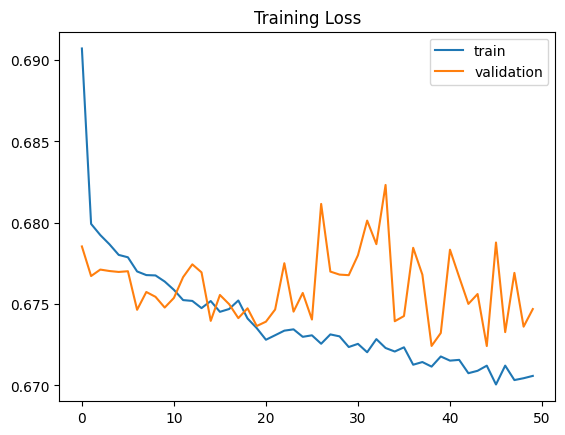

In [33]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["train","validation"])
plt.title("Training Loss")
plt.show()